# WIS2 Weather Station Exploration — trial & error before the v1_weather backend plan

**Feature #106** · requirements: [`docs/track-3/weather-wis2-backend-requirements.md`](docs/track-3/weather-wis2-backend-requirements.md)

Confirmed decisions this notebook validates against:
- Source: configurable **wis2box** instance, default `http://<WIS2_HOST>` (SwaziMet), OGC API — Features, no auth.
- Coverage: stations are **per region** (8 planned, 4 live). Inkhundla → region → station; no station ⇒ *"No data available"*.
- Ingestion: **daily midnight fetch** (Rundeck-triggered management command), no MQTT.
- Storage: **daily aggregates only** (station + parameter + day, with `readings_count`).
- Out of scope: 30-yr normals, SPI-3 (placeholder later); CHIRPS comparison is a separate feature — **simulated here** with the April 2026 `STEP_0303_*_pct_rank` rasters.

What this notebook must answer:
1. Real **archive depth / retention** of the instance (can we re-fetch history?).
2. Correct **precipitation aggregation rule** (SYNOP period semantics — double-count risk).
3. **Completeness / station-health** formulas from real gap patterns.
4. Station → **region assignment** and honest coverage map (which regions say "No data available").
5. Satellite-comparison **simulation** at station points / per region.
6. Draft **API response contracts** (generic-key style per CLAUDE.md).

In [1]:
import json
import math
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import rasterio.mask
import requests

# --- Configurable source (mirrors the future admin-editable setting) ---
WIS2_BASE = os.environ.get("WIS2_BASE", "http://<WIS2_HOST>")
OAPI = f"{WIS2_BASE}/oapi"
OBS_COLLECTION = os.environ.get(
    "WIS2_OBS_COLLECTION",
    "urn:wmo:md:sz-swazimet:eswatin-surface-observation-stations",
)

# Parameters the backend will serve (FR4)
PARAMS = [
    "total_precipitation_or_total_water_equivalent",
    "air_temperature",
    "maximum_temperature_at_height_and_over_period_specified",
    "minimum_temperature_at_height_and_over_period_specified",
]

ROOT = Path.cwd()
RES = ROOT / "resources"
DATA = ROOT / "data"
DATA.mkdir(exist_ok=True)
OBS_CACHE = DATA / "wis2_obs_cache.csv"

session = requests.Session()

def oapi_get(path, **params):
    r = session.get(f"{OAPI}/{path}", params={"f": "json", **params}, timeout=60)
    r.raise_for_status()
    return r.json()

def fetch_items(collection, max_pages=200, **params):
    """Fetch all features of a collection with offset pagination.

    GOTCHAS (both verified live — the backend ingester must defend against them):
    1. pygeoapi's `next` links DROP property filters like `wigos_station_identifier`,
       silently degrading page 2+ to a broader query -> paginate with explicit offset,
       resending every param.
    2. Filters are QUERY-PARAM-ORDER SENSITIVE: `wigos_station_identifier` is honored
       only when it appears AFTER `name` (name-first works; wigos-first is silently
       ignored). Defense in depth: verify each returned feature actually matches the
       requested filters, and dedupe on feature id.
    """
    url = f"{OAPI}/collections/{collection}/items"
    limit = 1000
    feats = []
    for page in range(max_pages):
        r = session.get(
            url,
            params={"f": "json", "limit": limit, "offset": page * limit, **params},
            timeout=60,
        )
        r.raise_for_status()
        batch = r.json().get("features", [])
        feats += batch
        if len(batch) < limit:
            break
    return feats

print("WIS2 source:", WIS2_BASE)

WIS2 source: http://<WIS2_HOST>


## 1 · Probe the instance — collections, stations, archive depth

In [2]:
cols = oapi_get("collections")
print("Collections on this instance:")
for c in cols["collections"]:
    print(" -", c["id"])

st_feats = fetch_items("stations")
stations = pd.DataFrame(
    {
        "wigos_id": f["properties"]["wigos_station_identifier"],
        "name": f["properties"]["name"],
        "status": f["properties"].get("status"),
        "lon": f["geometry"]["coordinates"][0],
        "lat": f["geometry"]["coordinates"][1],
        "elev_m": (f["geometry"]["coordinates"][2:] or [None])[0],
    }
    for f in st_feats
)
stations

Collections on this instance:
 - discovery-metadata
 - stations
 - messages
 - urn:wmo:md:sz-swazimet:eswatin-surface-observation-stations


,wigos_id,name,status,lon,lat,elev_m
0,0-748-0-68384,MOTI,operational,31.425500,-26.704200,341
1,0-20000-0-68394,LUBOVANE,operational,31.702222,-26.735833,265
2,0-20000-0-68391,MBABANE,operational,31.142700,-26.336000,1221
3,0-20000-0-68399,BIG BEND,operational,31.933000,-26.862600,129


In [3]:
# Archive depth: earliest & latest observation + total record count
def probe_edge(sort):
    d = oapi_get(f"collections/{OBS_COLLECTION}/items", limit=1, sortby=sort)
    f = d["features"][0]["properties"]
    return f["reportTime"], d.get("numberMatched")

earliest, total = probe_edge("+reportTime")
latest, _ = probe_edge("-reportTime")
span_days = (pd.Timestamp(latest) - pd.Timestamp(earliest)).days
print(f"Total observation records : {total:,}")
print(f"Earliest reportTime       : {earliest}")
print(f"Latest reportTime         : {latest}")
print(f"Archive span              : {span_days} days")
print()
print("=> RETENTION FINDING: if this span stays fixed while 'latest' advances,")
print("   the box purges old data and daily aggregates in our DB become the only history.")

Total observation records : 111,214
Earliest reportTime       : 2026-04-07T00:55:00Z
Latest reportTime         : 2026-07-15T05:54:00Z
Archive span              : 99 days

=> RETENTION FINDING: if this span stays fixed while 'latest' advances,
   the box purges old data and daily aggregates in our DB become the only history.


## 2 · Ingest full history for the 4 target parameters

Cached to `data/wis2_obs_cache.csv` so re-runs are offline-tolerant. Delete the file to force a re-fetch.

In [4]:
if OBS_CACHE.exists():
    obs = pd.read_csv(OBS_CACHE, parse_dates=["reportTime", "phen_start", "phen_end"])
    print(f"Loaded cache: {len(obs):,} rows")
else:
    rows = []
    for st in stations.wigos_id:
        for p in PARAMS:
            # name= MUST precede wigos_station_identifier= (order gotcha above)
            feats = fetch_items(OBS_COLLECTION, name=p, wigos_station_identifier=st)
            bad = [f for f in feats
                   if f["properties"]["wigos_station_identifier"] != st
                   or f["properties"]["name"] != p]
            assert not bad, f"API ignored a filter: {len(bad)} stray features"
            for f in feats:
                pr = f["properties"]
                pt = pr.get("phenomenonTime") or ""
                start, _, end = pt.partition("/")
                rows.append(
                    {
                        "obs_id": f["id"],
                        "wigos_id": pr["wigos_station_identifier"],
                        "param": pr["name"],
                        "value": pr["value"],
                        "units": pr["units"],
                        "reportTime": pr["reportTime"],
                        "phen_start": start,
                        "phen_end": end or start,
                        "reportId": pr["reportId"],
                    }
                )
            print(f"{st} {p}: {len(feats)}")
    obs = pd.DataFrame(rows).drop_duplicates("obs_id")  # belt-and-braces vs API quirks
    for c in ["reportTime", "phen_start", "phen_end"]:
        obs[c] = pd.to_datetime(obs[c], format="ISO8601")
    obs.to_csv(OBS_CACHE, index=False)
    print(f"Fetched {len(obs):,} rows -> {OBS_CACHE}")

obs["interval_h"] = (obs.phen_end - obs.phen_start).dt.total_seconds() / 3600
obs["date"] = obs.phen_end.dt.date
obs.groupby(["param"]).agg(rows=("value", "size"), stations=("wigos_id", "nunique"))

0-748-0-68384 total_precipitation_or_total_water_equivalent: 1412
0-748-0-68384 air_temperature: 1412
0-748-0-68384 maximum_temperature_at_height_and_over_period_specified: 1412
0-748-0-68384 minimum_temperature_at_height_and_over_period_specified: 1412
0-20000-0-68394 total_precipitation_or_total_water_equivalent: 2307
0-20000-0-68394 air_temperature: 2307
0-20000-0-68394 maximum_temperature_at_height_and_over_period_specified: 2307
0-20000-0-68394 minimum_temperature_at_height_and_over_period_specified: 2307
0-20000-0-68391 total_precipitation_or_total_water_equivalent: 2233
0-20000-0-68391 air_temperature: 2233
0-20000-0-68391 maximum_temperature_at_height_and_over_period_specified: 2233
0-20000-0-68391 minimum_temperature_at_height_and_over_period_specified: 2233
0-20000-0-68399 total_precipitation_or_total_water_equivalent: 590
0-20000-0-68399 air_temperature: 590
0-20000-0-68399 maximum_temperature_at_height_and_over_period_specified: 590
0-20000-0-68399 minimum_temperature_at_he

,rows,stations
param,,
air_temperature,6542,4
maximum_temperature_at_height_and_over_period_specified,6542,4
minimum_temperature_at_height_and_over_period_specified,6542,4
total_precipitation_or_total_water_equivalent,6542,4


In [5]:
# Precipitation period semantics — THE double-count check (Q4 contingency).
precip = obs[obs.param == PARAMS[0]]
print("Distribution of phenomenonTime interval lengths (hours) for precipitation:")
print(precip.interval_h.value_counts().sort_index().to_string())
print()
print("Per-station interval mix:")
print(precip.groupby(["wigos_id", "interval_h"]).size().unstack(fill_value=0).to_string())
print()
temps = obs[obs.param != PARAMS[0]]
print("Interval lengths for temperature params:")
print(temps.groupby(["param", "interval_h"]).size().to_string())

Distribution of phenomenonTime interval lengths (hours) for precipitation:
interval_h
1.0    6542

Per-station interval mix:
interval_h        1.0
wigos_id             
0-20000-0-68391  2233
0-20000-0-68394  2307
0-20000-0-68399   590
0-748-0-68384    1412

Interval lengths for temperature params:
param                                                    interval_h
air_temperature                                          0.0           6542
maximum_temperature_at_height_and_over_period_specified  24.0          6542
minimum_temperature_at_height_and_over_period_specified  24.0          6542


## 3 · Daily aggregation + completeness / station health

Aggregation rule (validated by the interval check above):
- **Precipitation**: sum only reports whose interval ≤ 1 h (each hour counted once). If a
  station-day has *no* hourly reports but has a 24 h report, use that instead.
- **Temperature**: daily Tmax = max(air_temperature ∪ max-temp reports), Tmin analogous,
  Tmean = mean(air_temperature).
- Every daily row carries `readings_count` (hourly air-temp reports received) vs expected 24 → completeness.
- Status (day-granular per Q3): `online` = data today/yesterday, `degraded` = completeness < 80 % over last 30 d, `offline` = no data ≥ 2 days.

In [6]:
p_hr = precip[precip.interval_h <= 1].groupby(["wigos_id", "date"]).value.sum()
p_24 = precip[precip.interval_h == 24].groupby(["wigos_id", "date"]).value.sum()
precip_daily = p_hr.combine_first(p_24).rename("precip_mm")  # hourly wins; 24h fills holes

at = obs[obs.param == "air_temperature"]
tmax_rep = obs[obs.param == PARAMS[2]].groupby(["wigos_id", "date"]).value.max()
tmin_rep = obs[obs.param == PARAMS[3]].groupby(["wigos_id", "date"]).value.min()
g = at.groupby(["wigos_id", "date"]).value
daily = pd.DataFrame(
    {
        "tmean": g.mean(),
        "tmax": pd.concat([g.max(), tmax_rep], axis=1).max(axis=1),
        "tmin": pd.concat([g.min(), tmin_rep], axis=1).min(axis=1),
        "readings_count": g.size(),
    }
).join(precip_daily, how="outer")
daily["completeness"] = (daily.readings_count.fillna(0) / 24).clip(0, 1)
print(f"{len(daily)} station-days")
daily.tail(8).round(2)

295 station-days


tmean   tmax   tmin  readings_count  precip_mm  \
wigos_id      date                                                         
0-748-0-68384 2026-07-08  14.09  26.95   5.35              24        0.0   
              2026-07-09  15.70  26.95   5.35              24        0.0   
              2026-07-10  17.35  25.95   8.15              24        0.0   
              2026-07-11  16.64  25.95   8.35              24        0.0   
              2026-07-12  18.22  24.45  11.25              24        0.0   
              2026-07-13  16.60  24.35  10.05              24        0.0   
              2026-07-14  16.27  24.85   9.65              24        0.0   
              2026-07-15   9.65  24.85   8.55               4        0.0   

                          completeness  
wigos_id      date                      
0-748-0-68384 2026-07-08          1.00  
              2026-07-09          1.00  
              2026-07-10          1.00  
              2026-07-11          1.00  
              2026-07-12          1.00  
              2026-07-13          1.00  
              2026-07-14          1.00  
              2026-07-15          0.17

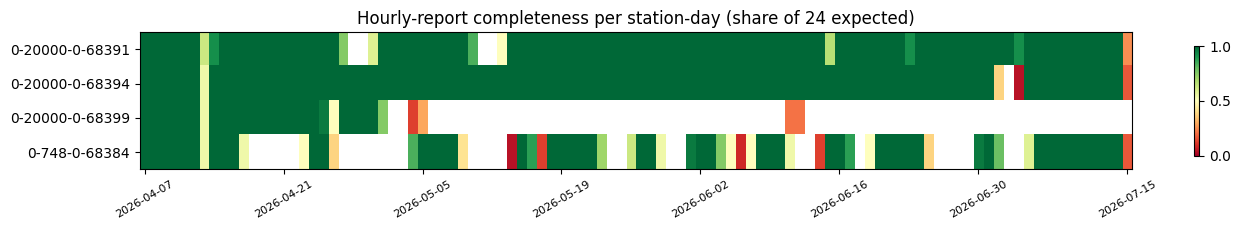

,last_reading,days_silent,completeness_30d,status
0-748-0-68384,2026-07-15,0,0.885,online
0-20000-0-68394,2026-07-15,0,0.919,online
0-20000-0-68391,2026-07-15,0,0.96,online
0-20000-0-68399,2026-06-12,33,NaN,offline


In [7]:
# Completeness heatmap + station health snapshot
piv = daily.reset_index().pivot_table(index="wigos_id", columns="date", values="completeness")
fig, ax = plt.subplots(figsize=(14, 2.4))
im = ax.imshow(piv.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_yticks(range(len(piv.index)), piv.index)
ticks = np.linspace(0, piv.shape[1] - 1, 8).astype(int)
ax.set_xticks(ticks, [str(piv.columns[i]) for i in ticks], rotation=30, fontsize=8)
ax.set_title("Hourly-report completeness per station-day (share of 24 expected)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

today = daily.reset_index().date.max()
def station_health(sid):
    d = daily.loc[sid]
    last = d.index.max()
    days_silent = (pd.Timestamp(today) - pd.Timestamp(last)).days
    comp30 = d[d.index >= (pd.Timestamp(today) - pd.Timedelta(days=30)).date()].completeness.mean()
    status = "offline" if days_silent >= 2 else ("degraded" if comp30 < 0.8 else "online")
    return {"last_reading": str(last), "days_silent": days_silent,
            "completeness_30d": round(float(comp30), 3), "status": status}

health = pd.DataFrame({s: station_health(s) for s in stations.wigos_id}).T
health

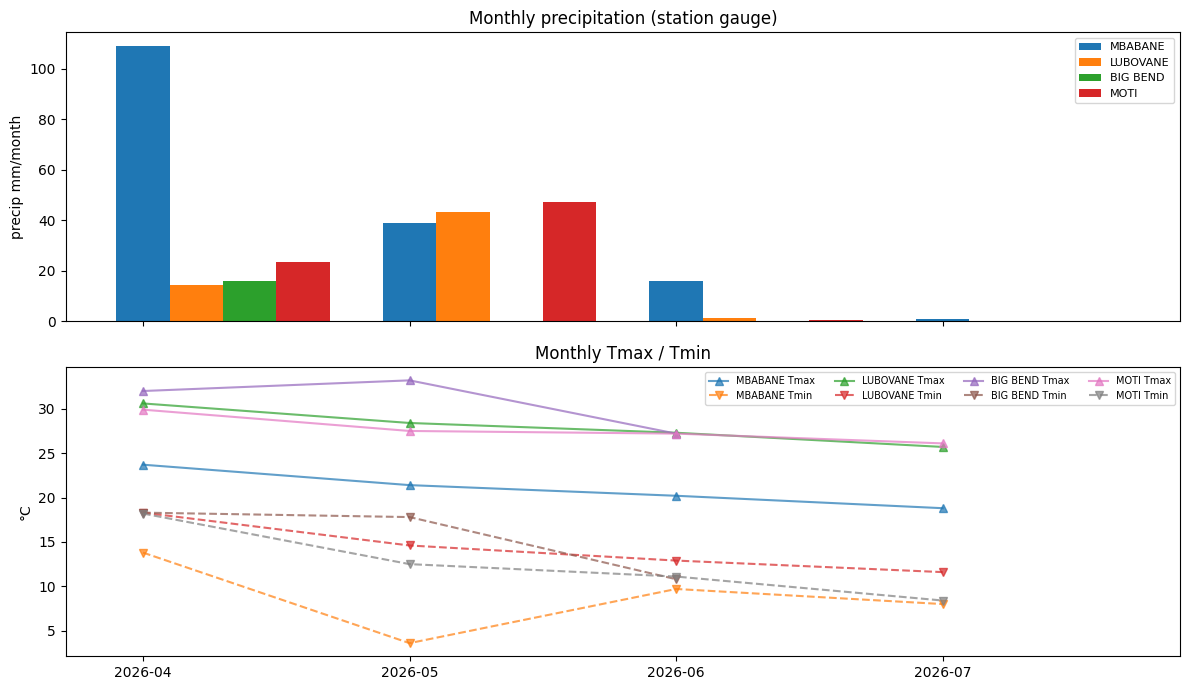

precip_mm  tmax  tmean  tmin  days_reporting
wigos_id        month                                                
0-20000-0-68391 2026-04      109.0  23.7   17.9  13.8              22
                2026-05       39.0  21.4   15.4   3.6              29
                2026-06       15.8  20.2   14.0   9.7              30
                2026-07        0.8  18.8   12.7   8.0              15
0-20000-0-68394 2026-04       14.6  30.6   22.6  18.3              24
                2026-05       43.2  28.4   20.5  14.6              31
                2026-06        1.4  27.3   18.9  12.9              30
                2026-07        0.0  25.7   16.9  11.6              14
0-20000-0-68399 2026-04       16.0  32.0   23.1  18.3              24
                2026-05        0.0  33.2   22.1  17.8               3
                2026-06        0.0  27.2   12.5  10.8               2
0-748-0-68384   2026-04       23.4  29.9   22.4  18.2              15
                2026-05       47.4  27.5   18.5  12.5              20
                2026-06        0.6  27.2   17.2  11.1              23
                2026-07        0.0  26.1   16.2   8.4              13

In [8]:
# Monthly aggregates — what FR4 will serve
daily_r = daily.reset_index()
daily_r["month"] = pd.to_datetime(daily_r.date.astype(str)).dt.to_period("M")
monthly = daily_r.groupby(["wigos_id", "month"]).agg(
    precip_mm=("precip_mm", "sum"),
    tmax=("tmax", "mean"),
    tmean=("tmean", "mean"),
    tmin=("tmin", "mean"),
    days_reporting=("readings_count", "size"),
).round(1)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
name_of = dict(zip(stations.wigos_id, stations.name))
mr = monthly.reset_index()
mr["m"] = mr.month.astype(str)
for i, (sid, gdf) in enumerate(mr.groupby("wigos_id")):
    axes[0].bar(np.arange(len(gdf)) + i * 0.2, gdf.precip_mm, width=0.2, label=name_of[sid])
    axes[1].plot(gdf.m, gdf.tmax, "^-", alpha=0.7, label=f"{name_of[sid]} Tmax")
    axes[1].plot(gdf.m, gdf.tmin, "v--", alpha=0.7, label=f"{name_of[sid]} Tmin")
axes[0].set_xticks(range(mr.m.nunique()), sorted(mr.m.unique()))
axes[0].set_ylabel("precip mm/month"); axes[0].legend(fontsize=8); axes[0].set_title("Monthly precipitation (station gauge)")
axes[1].set_ylabel("°C"); axes[1].legend(fontsize=7, ncol=4); axes[1].set_title("Monthly Tmax / Tmin")
plt.tight_layout(); plt.show()
monthly

## 4 · Map — stations vs regions, Tinkhundla and agro-ecological zones

Partner model: Inkhundla → **region** → station. Regions without a station ⇒ "No data available".

    region  n_inkhundla      stations_live           verdict
    Hhohho           15            MBABANE           covered
   Lubombo           11 LUBOVANE, BIG BEND           covered
   Manzini           18                NaN NO DATA AVAILABLE
Shiselweni           15               MOTI           covered


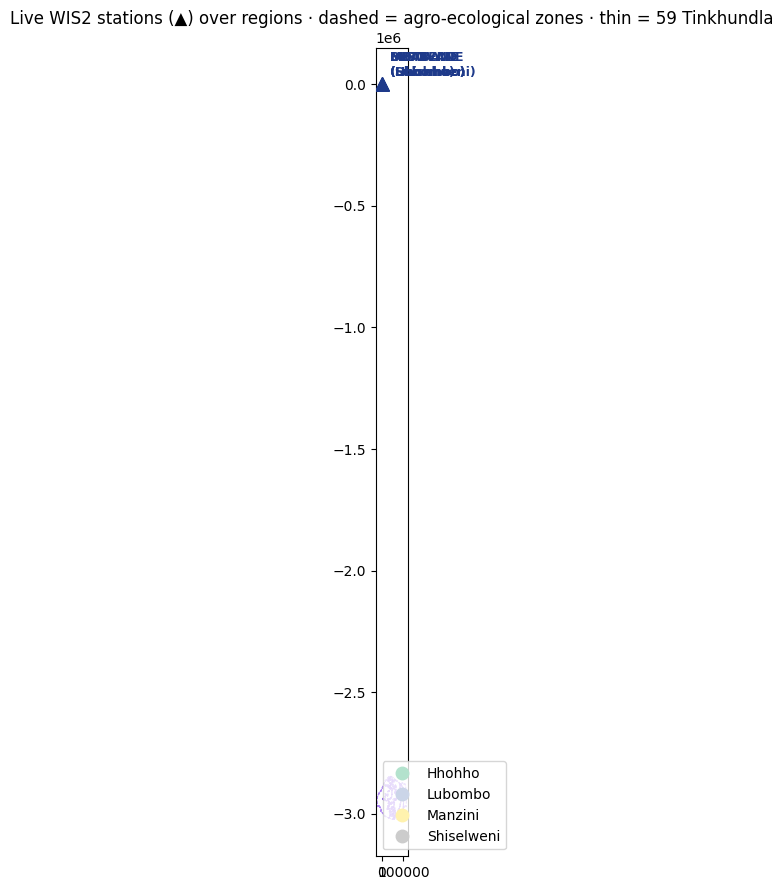

In [9]:
tink = gpd.read_file(RES / "eswatini.topojson").set_crs(4326)
aez = gpd.read_file(RES / "eswatini-ecological_regions.topojson").set_crs(4326)
regions = tink.dissolve(by="region", as_index=False)[["region", "geometry"]]

st_gdf = gpd.GeoDataFrame(
    stations, geometry=gpd.points_from_xy(stations.lon, stations.lat), crs=4326
)
st_gdf = gpd.sjoin(st_gdf, regions, how="left", predicate="within").drop(columns="index_right")
climzones = json.load(open(ROOT.parent / "backend" / "source" / "climatic-zones.json"))

coverage = regions.merge(
    st_gdf.groupby("region").name.apply(lambda s: ", ".join(s)).rename("stations_live"),
    on="region", how="left",
)
coverage["n_inkhundla"] = coverage.region.map(tink.groupby("region").size())
coverage["verdict"] = np.where(coverage.stations_live.notna(), "covered", 'NO DATA AVAILABLE')
print(coverage[["region", "n_inkhundla", "stations_live", "verdict"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 9))
regions.plot(ax=ax, column="region", cmap="Pastel2", edgecolor="#555", linewidth=1.2, legend=True)
aez.boundary.plot(ax=ax, color="#7c3aed", linewidth=0.7, linestyle="--", alpha=0.6)
tink.boundary.plot(ax=ax, color="#999", linewidth=0.3)
st_gdf.plot(ax=ax, color="#1e3a8a", markersize=90, marker="^", zorder=5)
for _, r in st_gdf.iterrows():
    ax.annotate(f"{r['name']}\n({r.region})", (r.lon, r.lat), xytext=(6, 6),
                textcoords="offset points", fontsize=9, fontweight="bold", color="#1e3a8a")
ax.set_title("Live WIS2 stations (▲) over regions · dashed = agro-ecological zones · thin = 59 Tinkhundla")
plt.tight_layout(); plt.show()

## 5 · Satellite comparison simulation (separate future feature)

April 2026 percentile-rank rasters (`STEP_0303_*_pct_rank_Eswatini_202604.tif`): CDI, ESI, EVI2, SM, SPI.
Sample each raster at the 4 station points and as a mean per region, then set alongside the
station-observed April 2026 aggregates (if the archive reaches back that far).

In [10]:
RASTERS = {p.stem.split("_")[2]: p for p in sorted(RES.glob("STEP_0303_*_202604.tif"))}
print("Rasters:", {k: v.name for k, v in RASTERS.items()})

pts = [(r.lon, r.lat) for _, r in st_gdf.iterrows()]
samp = {}
zonal = {}
for key, path in RASTERS.items():
    with rasterio.open(path) as src:
        nod = src.nodata
        vals = [v[0] for v in src.sample(pts)]
        samp[key] = [None if (v is None or (nod is not None and v == nod) or np.isnan(v)) else round(float(v), 3) for v in vals]
        zz = []
        for _, reg in regions.iterrows():
            arr, _ = rasterio.mask.mask(src, [reg.geometry], crop=True, filled=False)
            a = arr.compressed() if hasattr(arr, "compressed") else arr[~np.isnan(arr)]
            a = a[~np.isnan(a)] if a.dtype.kind == "f" else a
            if nod is not None:
                a = a[a != nod]
            zz.append(round(float(a.mean()), 3) if a.size else None)
        zonal[key] = zz

station_sat = pd.DataFrame(samp, index=st_gdf.name)
region_sat = pd.DataFrame(zonal, index=regions.region)
print("\nSatellite percentile ranks AT station points (April 2026):")
print(station_sat.to_string())
print("\nRegion-mean percentile ranks (April 2026):")
print(region_sat.to_string())

Rasters: {'CDI': 'STEP_0303_CDI_pct_rank_Eswatini_202604.tif', 'ESI': 'STEP_0303_ESI_pct_rank_Eswatini_202604.tif', 'EVI2': 'STEP_0303_EVI2_pct_rank_Eswatini_202604.tif', 'SM': 'STEP_0303_SM_pct_rank_Eswatini_202604.tif', 'SPI': 'STEP_0303_SPI_pct_rank_Eswatini_202604.tif'}

Satellite percentile ranks AT station points (April 2026):
          CDI    ESI   EVI2     SM    SPI
name                                     
MOTI      0.0  0.940  0.846  0.756  0.785
LUBOVANE  0.0  0.947  0.965  0.802  0.799
MBABANE   0.0  0.928  0.754  0.914  0.679
BIG BEND  0.0  0.957  0.929  0.843  0.814

Region-mean percentile ranks (April 2026):
              CDI    ESI   EVI2     SM    SPI
region                                       
Hhohho      0.103  0.945  0.851  0.903  0.776
Lubombo     0.107  0.961  0.862  0.857  0.770
Manzini     0.193  0.931  0.906  0.816  0.678
Shiselweni  0.255  0.927  0.843  0.806  0.756


Station archive covers April 2026 (from 2026-04-06 — note: month may be PARTIAL;
satellite rasters are full-April composites, so treat precip totals as lower bounds).


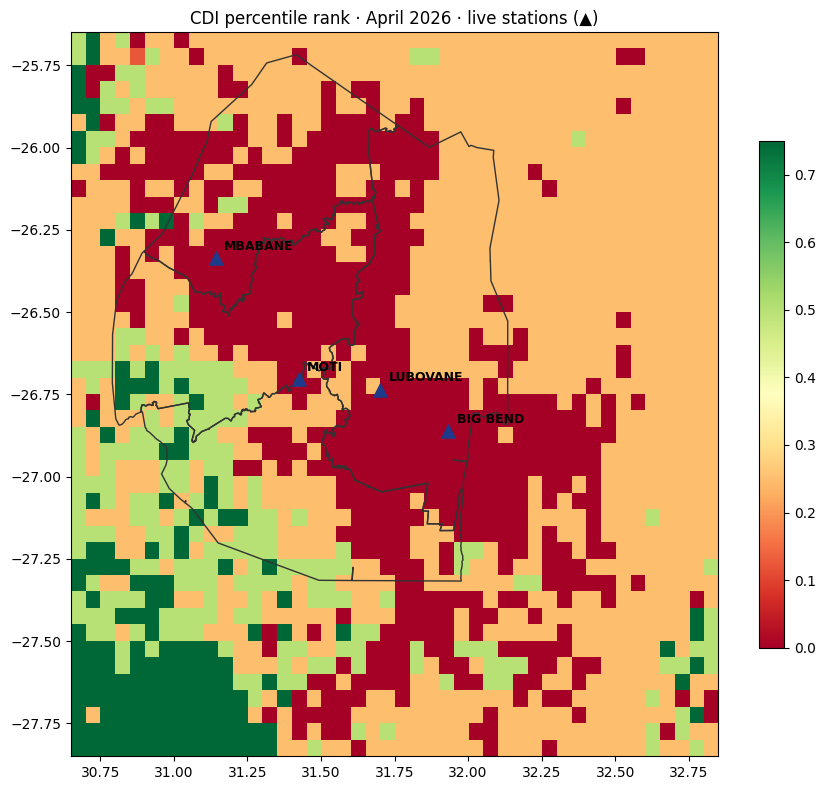

,precip_mm,tmean,days_reporting,CDI,ESI,EVI2,SM,SPI
name,,,,,,,,
MBABANE,109.0,17.9,22,0.0,0.928,0.754,0.914,0.679
LUBOVANE,14.6,22.6,24,0.0,0.947,0.965,0.802,0.799
BIG BEND,16.0,23.1,24,0.0,0.957,0.929,0.843,0.814
MOTI,23.4,22.4,15,0.0,0.940,0.846,0.756,0.785


In [11]:
# Station-observed April 2026 vs satellite — the comparison the future feature automates
mrz = monthly.reset_index()
apr = mrz[mrz.month == pd.Period("2026-04")].set_index("wigos_id")
if apr.empty:
    print("!! Station archive does NOT reach April 2026 — instance retention is shorter.")
    first_full = mrz.month.min()
    apr = mrz[mrz.month == first_full].set_index("wigos_id")
    print("   Comparing against earliest available month instead:", first_full)
else:
    print("Station archive covers April 2026 (from", obs.phen_start.min().date(), "— note: month may be PARTIAL;")
    print("satellite rasters are full-April composites, so treat precip totals as lower bounds).")
cmp_tbl = apr.join(stations.set_index("wigos_id").name).set_index("name")[
    ["precip_mm", "tmean", "days_reporting"]
].join(station_sat)
cmp_tbl

fig, ax = plt.subplots(figsize=(9, 8))
with rasterio.open(RASTERS["CDI"]) as src:
    arr = src.read(1).astype(float)
    if src.nodata is not None:
        arr[arr == src.nodata] = np.nan
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
im = ax.imshow(arr, extent=extent, cmap="RdYlGn", vmin=0, vmax=np.nanmax(arr))
regions.boundary.plot(ax=ax, color="#333", linewidth=1)
st_gdf.plot(ax=ax, color="#1e3a8a", markersize=90, marker="^", zorder=5)
for _, r in st_gdf.iterrows():
    ax.annotate(r["name"], (r.lon, r.lat), xytext=(6, 6), textcoords="offset points",
                fontsize=9, fontweight="bold")
ax.set_title("CDI percentile rank · April 2026 · live stations (▲)")
fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()
cmp_tbl

## 6 · Draft API response contracts

Generic-key shapes (`key` / `label` / `value` / `data` / `group` / `period` / `meta`) per CLAUDE.md,
built from **real data** above. Saved to `data/weather_api_contracts/` — these become
`frontend/src/static/mocks/` fixtures and later the Django serializer contracts.

In [12]:
CONTRACTS = DATA / "weather_api_contracts"
CONTRACTS.mkdir(exist_ok=True)

sid0 = stations.wigos_id.iloc[2]  # MBABANE
name0 = name_of[sid0]
mon0 = monthly.loc[sid0].reset_index()

# GET /api/v1/weather/stations
stations_resp = {
    "data": [
        {
            "key": r.wigos_id,
            "label": r.name.title(),
            "group": st_gdf.set_index("wigos_id").loc[r.wigos_id, "region"],
            "value": {"lat": r.lat, "lon": r.lon, "elevation": r.elev_m},
            "meta": {"status": health.loc[r.wigos_id, "status"],
                     "last_reading": health.loc[r.wigos_id, "last_reading"]},
        }
        for r in stations.itertuples()
    ],
    "meta": {"source": WIS2_BASE, "network": "MET", "total_planned": 8},
}

# GET /api/v1/weather/stations/<wigos_id>/monthly?parameter=precipitation
series_resp = {
    "key": sid0,
    "label": name0.title(),
    "group": "precipitation",
    "data": [
        {"period": str(r.month), "value": None if pd.isna(r.precip_mm) else r.precip_mm}
        for r in mon0.itertuples()
    ],
    "meta": {"units": "mm", "aggregation": "monthly_sum_of_daily"},
}

# GET /api/v1/weather/administrations/<administration_id>/latest  (review page, FR6)
covered_regions = set(st_gdf.region.dropna())
def adm_resp(adm):
    reg = adm["region"]
    if reg not in covered_regions:
        return {"key": adm["administration_id"], "label": adm["name"], "group": reg,
                "data": None, "meta": {"reason": "no_station_in_region"}}
    sid = st_gdf.set_index("region").loc[reg, "wigos_id"]
    sid = sid if isinstance(sid, str) else sid.iloc[0]
    m = monthly.loc[sid].iloc[-1]
    return {
        "key": adm["administration_id"], "label": adm["name"], "group": reg,
        "data": [
            {"key": "min_temperature", "label": "Min temperature", "value": m.tmin, "units": "°C"},
            {"key": "max_temperature", "label": "Max temperature", "value": m.tmax, "units": "°C"},
            {"key": "precipitation", "label": "Precipitation (monthly)", "value": m.precip_mm, "units": "mm"},
        ],
        "meta": {"station": name_of[sid].title(), "network": "MET",
                 "period": str(monthly.loc[sid].index[-1])},
    }

covered_ex = next(z for z in climzones if z["region"] in covered_regions)
uncovered_ex = next(z for z in climzones if z["region"] not in covered_regions)

contracts = {
    "stations_list.json": stations_resp,
    "station_monthly_series.json": series_resp,
    "administration_latest_covered.json": adm_resp(covered_ex),
    "administration_latest_no_data.json": adm_resp(uncovered_ex),
}
for fn, payload in contracts.items():
    (CONTRACTS / fn).write_text(json.dumps(payload, indent=2, default=str))
    print(f"--- {fn} " + "-" * (46 - len(fn)))
    print(json.dumps(payload, indent=2, default=str)[:900])
    print()

--- stations_list.json ----------------------------
{
  "data": [
    {
      "key": "0-748-0-68384",
      "label": "Moti",
      "group": "Shiselweni",
      "value": {
        "lat": -26.7042,
        "lon": 31.4255,
        "elevation": 341
      },
      "meta": {
        "status": "online",
        "last_reading": "2026-07-15"
      }
    },
    {
      "key": "0-20000-0-68394",
      "label": "Lubovane",
      "group": "Lubombo",
      "value": {
        "lat": -26.7358333333,
        "lon": 31.7022222222,
        "elevation": 265
      },
      "meta": {
        "status": "online",
        "last_reading": "2026-07-15"
      }
    },
    {
      "key": "0-20000-0-68391",
      "label": "Mbabane",
      "group": "Hhohho",
      "value": {
        "lat": -26.336,
        "lon": 31.1427,
        "elevation": 1221
      },
      "meta": {
        "status": "online",
        "last_reading": "2026-07-15"
      }
    },
    {
      "key":

--- station_monthly_series.json --------------

## Findings (executed 2026-07-15 against the live instance)

**1 · Archive depth / retention** — earliest observation **2026-04-07**, latest today: a
**99-day archive** (111k records). Whether this is a fixed retention window or just the
box's age is unknowable from one probe; either way it is shallow. ⇒ *our daily-aggregate
table becomes the only durable history — the storage decision (Q4) holds, and ingestion
must never lag by more than the retention window.*

**2 · Precipitation rule** — every precip report on this instance is a clean **1-hour
interval** (`phenomenonTime` start/end); no 3 h/24 h mixing today. Daily total = sum of
hourly reports; the 24 h-report fallback stays as a guard. Max/min temperature come as
**24 h-period reports**; `air_temperature` is instantaneous (hourly). Units: precip
`kg m-2` ≡ mm.

**3 · API gotchas (must be encoded in the backend ingester)** —
`next`-link pagination drops property filters, and filters are **query-param-order
sensitive** (`name` must precede `wigos_station_identifier`). Defenses: offset
pagination resending all params, client-side filter verification, dedupe on feature id.

**4 · Coverage (per-region model)** — Hhohho ⇒ MBABANE · Lubombo ⇒ LUBOVANE + BIG BEND ·
Shiselweni ⇒ MOTI · **Manzini (18 Tinkhundla) ⇒ "No data available"**. Also: **BIG BEND
has been silent since 2026-06-12** (33 days) while its `stations` metadata still says
`operational` ⇒ *station status must be computed from observed data, never trusted from
metadata.* The day-granular health formula (online / degraded < 80 % 30-day completeness /
offline ≥ 2 days silent) classified all 4 stations sensibly.

**5 · Satellite simulation** — sampling the April 2026 `STEP_0303` percentile-rank
rasters at station points and as region means works cleanly with rasterio; CDI at all 4
station pixels is ~0 (severe-drought percentile), consistent with region means of
0.10–0.26. Station April precip (partial month, from Apr 7) sits alongside satellite
ranks in the comparison table — the future feature automates exactly this join.

**6 · Contracts** — four generic-key response drafts saved to
`data/weather_api_contracts/`: stations list, station monthly series, per-Inkhundla
latest (covered), and per-Inkhundla latest (**no-data case for Manzini**).